## Problem Statement: Identify either note is Genuine or Fake note using predictive modelling  and with the help of Decision tree

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns

In [9]:
df = pd.read_csv('banknotes.csv')
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [10]:
# lets Create input and output data
X = df.drop(columns='Class')
X[:3]

,Variance,Skewness,Curtosis,Entropy
0,3.6216,8.6661,-2.8073,-0.44699
1,4.5459,8.1674,-2.4586,-1.46210
2,3.8660,-2.6383,1.9242,0.10645


In [11]:
y = df['Class']
y[:3]

0    0
1    0
2    0
Name: Class, dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [13]:
# splitting the dataset
from sklearn.model_selection import train_test_split

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=1)

In [15]:
X_train[:3]

,Variance,Skewness,Curtosis,Entropy
1226,-4.0679,2.4955,0.79571,-1.10390
1085,-2.6649,-12.8130,12.66890,-1.90820
148,3.6277,0.9829,0.68861,0.63403


In [16]:
y_test[:2]

1240    1
703     0
Name: Class, dtype: int64

In [17]:
y_train.value_counts(normalize=True)  # to get the percentage of the record

Class
0    0.551504
1    0.448496
Name: proportion, dtype: float64

In [18]:
# calculate the % of 0 and 1 in training data
y_train.value_counts()/len(y_train)*100

Class
0    55.15041
1    44.84959
Name: count, dtype: float64

In [19]:
# Import Descision tree algo
#from sklearn.tree import DecisionTreeRegressor

# current problem is binary classification problem
# hence classifier wil be used
from sklearn.tree import DecisionTreeClassifier

In [20]:
DecisionTreeClassifier?

Init signature:
DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    class_weight=None,
    ccp_alpha=0.0,
)
Docstring:     
A decision tree classifier.

Read more in the :ref:`User Guide <tree>`.

Parameters
----------
criterion : {"gini", "entropy", "log_loss"}, default="gini"
    The function to measure the quality of a split. Supported criteria are
    "gini" for the Gini impurity and "log_loss" and "entropy" both for the
    Shannon information gain, see :ref:`tree_mathematical_formulation`.

splitter : {"best", "random"}, default="best"
    The strategy used to choose the split at each node. Supported
    strategies are "best" to choose the best split and "random" to choose
    the best random split.

max_depth : int, default=None
    The maximum depth o

> Gini 	vs Entropy

> Low         High

> 0-0.5       0-1

> Faster	   Slower

>gini: Non log based
> entropy: log based calculation

In [21]:
model = DecisionTreeClassifier()  #DT is with its default arguments

In [22]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [23]:
model.classes_

array([0, 1], dtype=int64)

In [24]:
# prediction
y_pred = model.predict(X_test)
y_pred[:5] #predicted result

array([1, 0, 1, 1, 0], dtype=int64)

In [25]:
y_test[:5].values #actual result

array([1, 0, 1, 1, 0], dtype=int64)

In [26]:
# Lets check trianing data score
model.score(X_train,y_train)*100

100.0

In [27]:
model.score(X_test,y_test)*100

98.9090909090909

In [28]:
#performance metrics
from sklearn.metrics import confusion_matrix,classification_report

In [29]:
confusion_matrix(y_test,y_pred)

array([[154,   3],
       [  0, 118]], dtype=int64)

In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       157
           1       0.98      1.00      0.99       118

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



In [31]:
model.criterion

'gini'

## Lets change criterion= 'entropy'

In [32]:
# Lest apply entropy
model2 = DecisionTreeClassifier(criterion='entropy')

In [33]:
model2.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [34]:
y_pred2 = model2.predict(X_test)
y_pred2[:6]

array([1, 0, 1, 1, 0, 0], dtype=int64)

In [35]:
confusion_matrix(y_test,y_pred2)

array([[157,   0],
       [  0, 118]], dtype=int64)

In [36]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       157
           1       1.00      1.00      1.00       118

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



# DT visualization

In [37]:
from sklearn import tree

In [38]:
X = df.iloc[:,:-1]
X[:2]

,Variance,Skewness,Curtosis,Entropy
0,3.6216,8.6661,-2.8073,-0.44699
1,4.5459,8.1674,-2.4586,-1.46210


In [39]:
X.columns

Index(['Variance', 'Skewness', 'Curtosis', 'Entropy'], dtype='object')

In [40]:
model2

DecisionTreeClassifier(criterion='entropy')

#### Textual representation of Decision Tree

In [41]:
model2.classes_

array([0, 1], dtype=int64)

In [42]:
tree

<module 'sklearn.tree' from 'c:\\Users\\Shridhar\\anaconda3\\Lib\\site-packages\\sklearn\\tree\\__init__.py'>

In [43]:
# to get a textual representation  of a model and its data wil use export_text method
text_representation = tree.export_text(model2,feature_names=['Variance', 'Skewness', 'Curtosis', 'Entropy'],
                                      class_names=['Fake','Genuine'])
print(text_representation)

|--- Variance <= 0.77
|   |--- Skewness <= 5.36
|   |   |--- Curtosis <= 0.75
|   |   |   |--- class: Genuine
|   |   |--- Curtosis >  0.75
|   |   |   |--- Variance <= -0.46
|   |   |   |   |--- Skewness <= 0.71
|   |   |   |   |   |--- Variance <= -1.51
|   |   |   |   |   |   |--- class: Genuine
|   |   |   |   |   |--- Variance >  -1.51
|   |   |   |   |   |   |--- Entropy <= -0.50
|   |   |   |   |   |   |   |--- class: Fake
|   |   |   |   |   |   |--- Entropy >  -0.50
|   |   |   |   |   |   |   |--- class: Genuine
|   |   |   |   |--- Skewness >  0.71
|   |   |   |   |   |--- Curtosis <= 3.93
|   |   |   |   |   |   |--- class: Genuine
|   |   |   |   |   |--- Curtosis >  3.93
|   |   |   |   |   |   |--- class: Fake
|   |   |   |--- Variance >  -0.46
|   |   |   |   |--- Entropy <= 0.73
|   |   |   |   |   |--- Curtosis <= 1.12
|   |   |   |   |   |   |--- Entropy <= -0.07
|   |   |   |   |   |   |   |--- class: Fake
|   |   |   |   |   |   |--- Entropy >  -0.07
|   |   |   | 

In [44]:
import matplotlib.pyplot as plt

In [45]:
X.shape

(1372, 4)

In [46]:
X_train.shape

(1097, 4)

In [47]:
y_train.value_counts()

Class
0    605
1    492
Name: count, dtype: int64

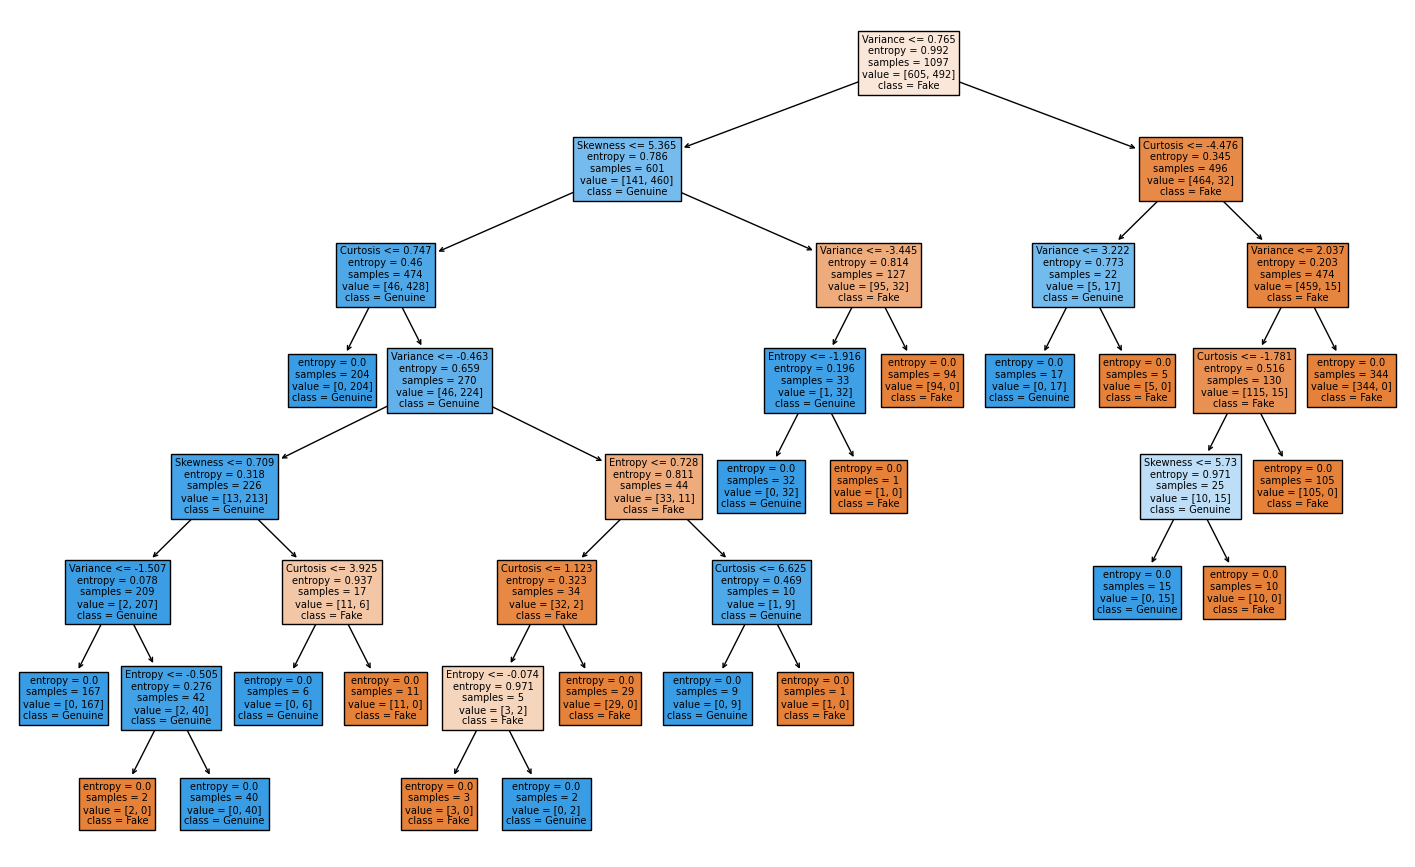

In [48]:
fig = plt.figure(figsize=(18,11))
_ = tree.plot_tree(model2,
                   feature_names=['Variance', 'Skewness', 'Curtosis', 'Entropy'],
                   class_names=['Fake','Genuine'],
                   filled=True)
plt.savefig('july_tree.png',dpi=80)

In [49]:
len(X_train)

1097

In [50]:
sum(y_train==0),sum(y_train==1)

(605, 492)

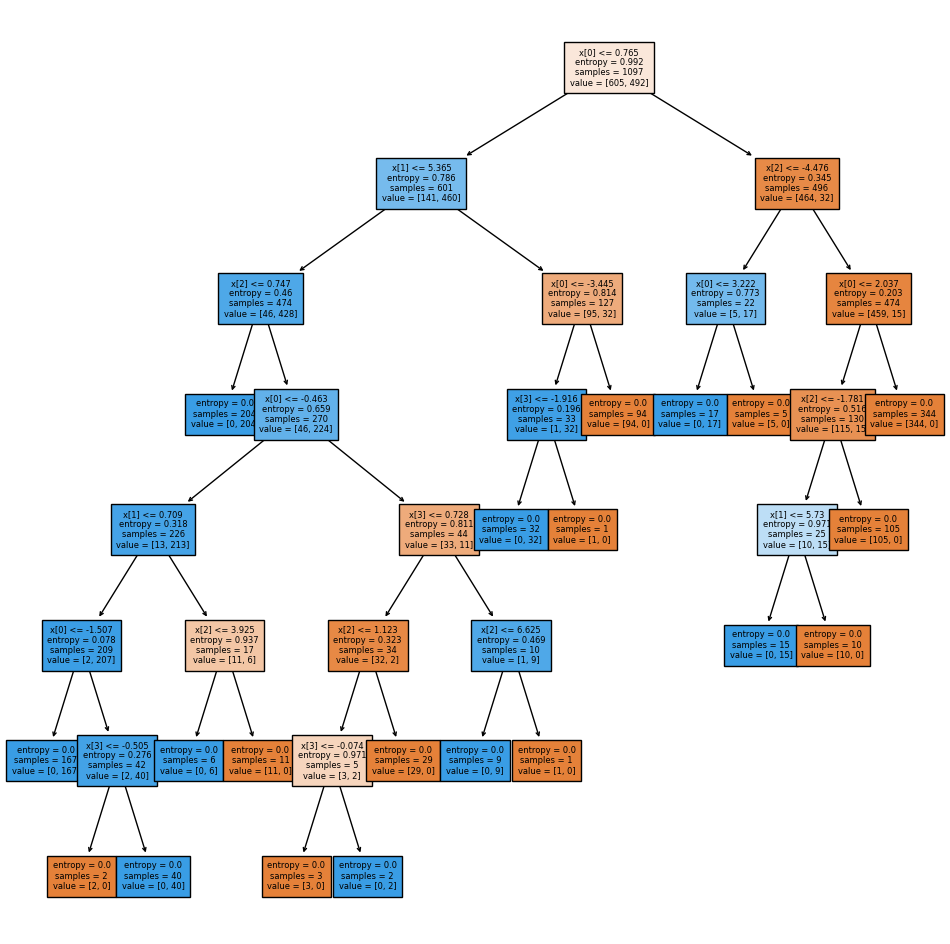

In [51]:
plt.figure(figsize=(12,12))
tree.plot_tree(model2, fontsize=6,filled=True)
plt.savefig('cns_tree_high_dpi', dpi=300)

### **Use California housing dataset to build a model with DT to predict median_house_value**

In [52]:
# Assignment
cal = pd.read_csv('/content/sample_data/california_housing_train.csv')
cal.head(2)

FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/california_housing_train.csv'

# Cross Validation

## **What is Cross-Validation?**
>Cross validation is a technique used in machine learning to evaluate the performance of a model on unseen data. It involves dividing the available data into multiple folds or subsets, using one of these folds as a validation set, and training the model on the remaining folds. This process is repeated multiple times, each time using a different fold as the validation set. Finally, the results from each validation step are averaged to produce a more robust estimate of the model’s performance.

https://www.geeksforgeeks.org/cross-validation-machine-learning/

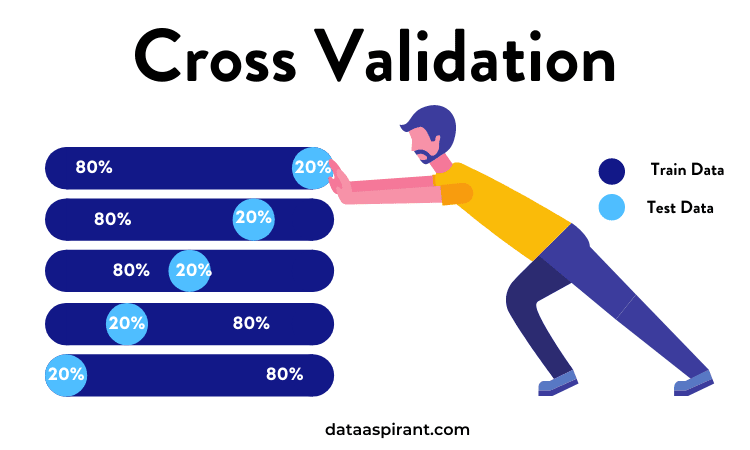

In [1]:
X_train[:3]

NameError: name 'X_train' is not defined

In [ ]:
from sklearn.model_selection import cross_val_score #1

In [ ]:
cross_val_score?

>cross_val_score(estimator=Model, X, y=None, *, scoring=function, cv=no_of_Folds, n_jobs=processor: -1(use all cores))

In [ ]:
model2

DecisionTreeClassifier(criterion='entropy')

In [ ]:
X[:4]

,Variance,Skewness,Curtosis,Entropy
0,3.6216,8.6661,-2.8073,-0.44699
1,4.5459,8.1674,-2.4586,-1.46210
2,3.8660,-2.6383,1.9242,0.10645
3,3.4566,9.5228,-4.0112,-3.59440


In [ ]:
y[:4]

,Class
0,0
1,0
2,0
3,0


In [ ]:
y.unique()

In [ ]:
X.shape

(1372, 4)

- total records: 1372
- cv(folds) = 10
- final records in test phase = 1372/10 = 137 approx.

In [ ]:
1372/10   # number of records in Test data

137.2

In [ ]:
137*10

1370

In [ ]:
cv_score = cross_val_score(model2,X,y,cv=10)
#default cv value is =5 means it will give us five folds
cv_score  # giving us accuracy for 10 different folds

array([0.99275362, 0.98550725, 0.98540146, 0.98540146, 0.98540146,
       0.98540146, 0.98540146, 0.98540146, 0.99270073, 0.98540146])

- Default scoring function for classification is Accuracy
- Default scoring function for regression is r2_score


In [ ]:
pre_cv_score = cross_val_score(model2,X,y,scoring='precision', cv=5)
pre_cv_score

array([0.97560976, 0.98373984, 0.99180328, 0.97580645, 0.99180328])

In [ ]:
res_1 = cv_score.mean()*100
res_1  # average accuracy for DT with 10 folds is 98+

np.float64(98.68771818470327)

In [ ]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()

In [ ]:
res_2 = cross_val_score(LR,X,y)
res_2

array([0.98909091, 0.98909091, 0.98175182, 1.        , 0.98905109])

In [ ]:
res_2 = res_2.mean()*100
res_2

np.float64(98.97969475779695)

In [ ]:
from sklearn.naive_bayes import GaussianNB
gb = GaussianNB()

In [ ]:
res_3 = cross_val_score(gb,X,y).mean()*100
res_3

np.float64(83.82057067020571)

In [ ]:
# lets us svm
from sklearn.svm import SVC
res_4 = cross_val_score(SVC(),X,y).mean()*100
res_4

np.float64(99.78128732581285)

In [ ]:
pd.DataFrame({'DT':[res_1],'LogisticR':[res_2],'GaussianNB':[res_3],'SVC':[res_4]}).T.sort_values(by=0)

,0
GaussianNB,83.820571
DT,98.687718
LogisticR,98.979695
SVC,99.781287


Finding_2: We have cross validated 4 algorthims out of which SVC performed well with highest 99% of accuracy.  

In [ ]:
# my problem is classification and i m using Regression
from sklearn.linear_model import LinearRegression
cross_val_score(LinearRegression(),X,y).mean()*100

np.float64(15.392872466058197)

# Hyperparameter tuning using GridSearch CV

https://www.kdnuggets.com/hyperparameter-tuning-gridsearchcv-and-randomizedsearchcv-explained

In [ ]:
import pandas as pd
df = pd.read_csv('banknotes.csv')
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
X = df.iloc[:,:-1]
X[:2]

,Variance,Skewness,Curtosis,Entropy
0,3.6216,8.6661,-2.8073,-0.44699
1,4.5459,8.1674,-2.4586,-1.46210


In [ ]:
y = df['Class']
y[:2]

,Class
0,0
1,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
DecisionTreeClassifier?

In [ ]:
# lets use a DT model with default parameters
m1 = DecisionTreeClassifier()
m1.fit(X_train,y_train)
print(m1.score(X_train,y_train)*100)
print(m1.score(X_test,y_test)*100)

100.0
97.81818181818181


In [ ]:
#lets change some parameter values
m2 = DecisionTreeClassifier(criterion='entropy',
    splitter='random',
    max_depth=4,
    min_samples_split=2,
    min_samples_leaf=2,
    min_weight_fraction_leaf=0.5)
m2.fit(X_train,y_train)
print(m2.score(X_train,y_train)*100)
print(m2.score(X_test,y_test)*100)

55.78851412944393
54.54545454545454


In [ ]:
# In HyperParamter tuning following algorithms we can prefer
# - GridSearchCV
# - RandomizedSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
GridSearchCV?

In [ ]:
"""
GridSearchCV(
    estimator,--> object of algorithm
    param_grid,---> dict of parameter and its multiple options

GridSearchCV(m1,pr_grid)
m1: ML model =SVC()
pr_grid: parameter grid in the form of dict= see below example
"""

In [ ]:
pr_grid = {
    'criterion':['gini','entropy','log_loss'],
    'splitter':['best','random'],
    'max_depth':[2,3,4,5,6,8],
    'min_samples_split':[2,3],
    'min_samples_leaf':[1,2,3,4,5],
    'min_weight_fraction_leaf':[0.0,0.2,0.4,0.5]
    }

In [ ]:
pr_grid

In [ ]:
"""
GridSearchCV(
    estimator,
    param_grid,
"""
#model = DecisionTreeClassifier()
print(m1)
#lets create an object of GridSearchCV
out = GridSearchCV(m1,pr_grid)

DecisionTreeClassifier()


In [ ]:
# normal we prefer 10 fold cross validation i mean cv = 10
from sklearn.model_selection import cross_val_score
cross_val_score(m1,X,y).mean()

np.float64(0.9803238221632384)

In [ ]:
cross_val_score(m1,X,y,cv=10).mean()

np.float64(0.984687400825135)

In [ ]:
out

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [2, 3, 4, 5, 6, 8],
                         'min_samples_leaf': [1, 2, 3, 4, 5],
                         'min_samples_split': [2, 3],
                         'min_weight_fraction_leaf': [0.0, 0.2, 0.4, 0.5],
                         'splitter': ['best', 'random']})

In [ ]:
X[:2]

In [ ]:
y[:2]

In [ ]:
# Train ove X and Y using GridSearchCV object
out.fit(X,y)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [2, 3, 4, 5, 6, 8],
                         'min_samples_leaf': [1, 2, 3, 4, 5],
                         'min_samples_split': [2, 3],
                         'min_weight_fraction_leaf': [0.0, 0.2, 0.4, 0.5],
                         'splitter': ['best', 'random']})

In [ ]:
pr_grid

{'criterion': ['gini', 'entropy', 'log_loss'],
 'splitter': ['best', 'random'],
 'max_depth': [2, 3, 4, 5, 6, 8],
 'min_samples_split': [2, 3],
 'min_samples_leaf': [1, 2, 3, 4, 5],
 'min_weight_fraction_leaf': [0.0, 0.2, 0.4, 0.5]}

In [ ]:
out.best_params_

{'criterion': 'entropy',
 'max_depth': 8,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'splitter': 'best'}

In [ ]:
out.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=8)

In [ ]:
# after getting best estimators build final ML model
final = DecisionTreeClassifier(criterion='entropy', max_depth=8)

In [ ]:
final.fit(X,y)

DecisionTreeClassifier(criterion='entropy', max_depth=8)

In [ ]:
final.score(X,y)*100

100.0

In [ ]:
final.score(X_train,y_train)*100

100.0

In [ ]:
final.score(X_test,y_test)*100

100.0

### **Use m2 model and pr_grid to apply GridSearchCV**

In [ ]:
m2

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=2,
                       min_weight_fraction_leaf=0.5, splitter='random')

In [ ]:
pr_grid

{'criterion': ['gini', 'entropy', 'log_loss'],
 'splitter': ['best', 'random'],
 'max_depth': [2, 3, 4, 5, 6, 8],
 'min_samples_split': [2, 3],
 'min_samples_leaf': [1, 2, 3, 4, 5],
 'min_weight_fraction_leaf': [0.0, 0.2, 0.4, 0.5]}

In [ ]:
# Assignment: Apply RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
RandomizedSearchCV?

**Q> List out the difference between GridSearchCV and RandomizedSearchCV**